# Week 9 — OU density discovery with camera errors

This notebook extends the Week 7 Euler--Maruyama (EM) density experiment without changing the underlying Ornstein--Uhlenbeck model. It introduces camera errors at the **trajectory level**, reconstructs four density datasets on one common grid, and applies the same five-candidate and fifteen-candidate Weak-SINDy libraries to every dataset.

The four observation conditions are:

1. **Clean:** instantaneous latent positions at camera-frame midpoints;
2. **Motion blur:** top-hat exposure averages over each camera interval;
3. **Localisation only:** clean positions plus independent Gaussian localisation noise;
4. **Blur + localisation:** exposure averages plus the same Gaussian localisation noise.

The notebook deliberately keeps the physical OU equation fixed:

$$
dX_t=-\kappa X_t\,dt+\sqrt{2D}\,dW_t,
\qquad
\rho_t=\kappa\,\partial_x(x\rho)+D\rho_{xx}.
$$

Camera errors are applied before constructing histograms. Adding random values directly to the density would represent a different observation model.


## 1. Camera observation model

Let one camera frame cover the interval $[t_\alpha,t_\alpha+\Delta t_{\rm cam}]$. For constant illumination, the motion-blurred position is the top-hat average

$$
X^{\rm blur}_{m,\alpha}
=\frac{1}{\Delta t_{\rm cam}}
\int_{t_\alpha}^{t_\alpha+\Delta t_{\rm cam}}X_m(s)\,ds.
$$

The code approximates this integral on the fine EM grid using the trapezoidal rule. The clean comparison uses the latent position at the midpoint of exactly the same camera interval. Hence all four conditions have identical camera times and array shapes.

Localisation error is added independently to every particle and frame:

$$
X^{\rm loc}_{m,\alpha}
=X^{\rm clean}_{m,\alpha}+\varepsilon_{m,\alpha},
\qquad
\varepsilon_{m,\alpha}\overset{\rm iid}{\sim}
\mathcal N(0,\sigma_{\rm loc}^2).
$$

We parameterise its strength by

$$
\widetilde\sigma
=\frac{\sigma_{\rm loc}}{\sqrt{2D\Delta t_{\rm cam}}},
$$

so $\widetilde\sigma=1$ means that the localisation standard deviation equals the typical one-dimensional Brownian displacement over one camera interval.


In [1]:
# ============================================================
# Imports
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pysindy as ps

from IPython.display import Math, display

In [2]:
# ============================================================
# Shared OU, EM, camera, histogram, and Weak-SINDy parameters
# ============================================================

# Physical OU parameters (same as Week 7)
kappa = 1.0
D = 1.0

m0 = -2.0
s0 = 0.5

# Physical domain and final time
x_L = -5.0
x_R = 5.0
T_final = 3.0

# Histogram resolution: Reuse the Nx_em+1 Week-7 spatial grid points
# as histogram bin centres.
Nx_em = 50

# Camera output resolution
Nt_camera = 75

dt_camera = T_final / Nt_camera

# Fine EM resolution inside every camera interval
substeps_per_camera_frame = 20
Nt_internal_em = Nt_camera * substeps_per_camera_frame
dt_internal_em = T_final / Nt_internal_em

# Monte Carlo ensemble
num_paths_em = 60_000
trajectory_seed = 319

# Camera localisation noise. Try 0.25, 0.5, 1.0 for a sweep.
sigma_tilde = 0.5
sigma_loc = sigma_tilde * np.sqrt(2.0 * D * dt_camera)
camera_noise_seed = 801

# Weak-SINDy settings. 
# Week 7 found a 25% requested full width
# to be the safest common choice for both the 5- and 15-term libraries.
K_weak = 500
subdomain_full_width_fraction = 0.25
weak_subdomain_seed = 2002
stlsq_threshold = 0.1
stlsq_alpha = 1e-10

if substeps_per_camera_frame % 2 != 0:
    raise ValueError(
        "Use an even number of fine substeps so the camera midpoint "
        "lies exactly on the internal EM grid."
    )

print(f"Internal EM dt:          {dt_internal_em:.6f}")
print(f"Camera-frame dt:         {dt_camera:.6f}")
print(f"Fine steps per frame:    {substeps_per_camera_frame}")
print(f"Number of camera frames: {Nt_camera}")
print(f"Number of paths:         {num_paths_em:,}")
print(f"sigma_tilde:             {sigma_tilde:.3f}")
print(f"sigma_loc:               {sigma_loc:.6f}")

Internal EM dt:          0.002000
Camera-frame dt:         0.040000
Fine steps per frame:    20
Number of camera frames: 75
Number of paths:         60,000
sigma_tilde:             0.500
sigma_loc:               0.141421


## 2. Camera-aware OU coefficient reference

For a continuous top-hat exposure of duration
$\Delta t_{\mathrm{cam}}$, define

$$
z=\kappa\Delta t_{\mathrm{cam}}.
$$

The marginal variance of the motion-blurred OU observation has the same
exponential relaxation rate as the physical OU process, but its stationary
variance is reduced by temporal averaging. The corresponding effective
diffusion coefficient is

$$
D_{\mathrm{blur}}
=
D\frac{2(z-1+e^{-z})}{z^2}.
$$

Independent Gaussian localisation error adds $\sigma_{\mathrm{loc}}^2$ to
the observed variance. Therefore,

$$
D_{\mathrm{loc}}
=
D+\kappa\sigma_{\mathrm{loc}}^2,
$$

and

$$
D_{\mathrm{blur+loc}}
=
D_{\mathrm{blur}}
+\kappa\sigma_{\mathrm{loc}}^2.
$$

These references describe the marginal observed density in the
linear-Gaussian OU setting. They do not imply that arbitrary camera errors
preserve the governing PDE structure.

In [3]:
z_camera = kappa * dt_camera

if np.isclose(z_camera, 0.0):
    blur_diffusion_factor = 1.0
else:
    # z - 1 + exp(-z) = z + expm1(-z)
    blur_diffusion_factor = (
        2.0
        * (
            z_camera
            + np.expm1(-z_camera)
        )
        / z_camera**2
    )

D_blur_reference = (
    D * blur_diffusion_factor
)

D_localisation_reference = (
    D
    + kappa * sigma_loc**2
)

D_blur_localisation_reference = (
    D_blur_reference
    + kappa * sigma_loc**2
)

camera_diffusion_reference = {
    "clean": D,
    "motion_blur": D_blur_reference,
    "localisation_only": D_localisation_reference,
    "blur_and_localisation": D_blur_localisation_reference,
}

camera_reference_table = pd.DataFrame({
    "Condition": list(camera_diffusion_reference.keys()),
    "Physical D": D,
    "Camera-aware D": list(camera_diffusion_reference.values()),
})

display(
    camera_reference_table.style.format({
        "Physical D": "{:.6f}",
        "Camera-aware D": "{:.6f}",
    }).set_caption("Physical and camera-aware diffusion references")
)

,Condition,Physical D,Camera-aware D
0,clean,1.000000,1.000000
1,motion_blur,1.000000,0.986799
2,localisation_only,1.000000,1.020000
3,blur_and_localisation,1.000000,1.006799


## 3. Exact OU reference and shared helper functions

For the initial Gaussian distribution $X_0\sim\mathcal N(m_0,s_0^2)$, the exact mean and variance are

$$
m(t)=m_0e^{-\kappa t},
\qquad
v(t)=s_0^2e^{-2\kappa t}
+\frac{D}{\kappa}\left(1-e^{-2\kappa t}\right).
$$

They provide an independent reference for the clean EM histogram. The camera-corrupted densities are compared both with this physical reference and with the clean histogram constructed from the same latent trajectories.


In [4]:
def exact_ou_moments(t_grid, kappa, D, m0, s0):
    """Return the exact OU mean and variance."""

    t_grid = np.asarray(t_grid, dtype=float)
    mean = m0 * np.exp(-kappa * t_grid)
    variance = (
        s0**2 * np.exp(-2.0 * kappa * t_grid)
        + (D / kappa) * (1.0 - np.exp(-2.0 * kappa * t_grid))
    )
    return mean, variance


def exact_ou_density(x_grid, t_grid, kappa, D, m0, s0):
    """Exact density of dX = -kappa X dt + sqrt(2D) dW."""

    mean, variance = exact_ou_moments(t_grid, kappa, D, m0, s0)
    return (
        np.exp(-0.5 * (x_grid - mean) ** 2 / variance)
        / np.sqrt(2.0 * np.pi * variance)
    )


def relative_l2_error(approximation, reference):
    """Relative Euclidean L2 error after flattening both arrays."""

    approximation = np.asarray(approximation).ravel()
    reference = np.asarray(reference).ravel()
    denominator = np.linalg.norm(reference)

    if denominator == 0.0:
        raise ZeroDivisionError("The reference array has zero L2 norm.")

    return np.linalg.norm(approximation - reference) / denominator


def print_identified_equation(feature_names, coefficients, tolerance=1e-10):
    """Display one identified PDE using rendered LaTeX."""

    terms = []
    for name, coefficient in zip(feature_names, coefficients):
        if abs(coefficient) > tolerance:
            terms.append((np.sign(coefficient), abs(coefficient), name.strip("$")))

    if not terms:
        right_hand_side = "0"
    else:
        first_sign, first_magnitude, first_name = terms[0]
        prefix = "-" if first_sign < 0 else ""
        right_hand_side = f"{prefix}{first_magnitude:.6f}\\,{first_name}"

        for sign, magnitude, name in terms[1:]:
            operator = "+" if sign > 0 else "-"
            right_hand_side += f" {operator} {magnitude:.6f}\\,{name}"

    display(Math(rf"\rho_t={right_hand_side}"))


## 4. Simulate latent OU trajectories and apply the camera model

The simulator is self-contained; it does not require `ou_em.py`. It advances only the current particle vector, so it never stores all 1501 fine-time positions. During each camera interval it records:

- the instantaneous position at the interval midpoint (`clean`);
- the trapezoidal top-hat average over the full interval (`motion_blur`).

After the physical trajectories are complete, one common Gaussian error array is used to create `localisation_only` and `blur_and_localisation`. Reusing the same error realisation gives a paired comparison: the difference between those two datasets is caused only by motion blur.


In [5]:
def simulate_ou_camera_ensemble(
    num_paths,
    n_camera_frames,
    substeps_per_frame,
    dt_internal,
    kappa,
    D,
    m0,
    s0,
    sigma_loc,
    trajectory_seed=319,
    camera_noise_seed=801,
):
    """Simulate OU trajectories and four camera observation conditions.

    Returns
    -------
    t_camera : (n_camera_frames,) array
        Midpoint time of every camera exposure window.
    positions : dict of arrays, each shape (num_paths, n_camera_frames)
        clean, motion_blur, localisation_only, blur_and_localisation.

    Notes
    -----
    Motion blur is a top-hat exposure integral approximated by the
    trapezoidal rule on the internal EM time grid. Only camera-time arrays
    are retained, which avoids storing the full fine trajectory tensor.
    """

    if num_paths < 1:
        raise ValueError("num_paths must be positive.")
    if n_camera_frames < 2:
        raise ValueError("At least two camera frames are required.")
    if substeps_per_frame < 2 or substeps_per_frame % 2 != 0:
        raise ValueError("substeps_per_frame must be an even integer >= 2.")
    if min(kappa, D, s0, sigma_loc) < 0:
        raise ValueError("kappa, D, s0 and sigma_loc must be non-negative.")

    physical_rng = np.random.default_rng(trajectory_seed)
    camera_rng = np.random.default_rng(camera_noise_seed)

    X_current = physical_rng.normal(m0, s0, size=num_paths)

    clean = np.empty((num_paths, n_camera_frames), dtype=np.float32)
    blurred = np.empty_like(clean)

    midpoint_substep = substeps_per_frame // 2
    noise_scale = np.sqrt(2.0 * D * dt_internal)

    for frame in range(n_camera_frames):
        # The top-hat integral starts with half the left endpoint.
        trapezoid_sum = 0.5 * X_current
        midpoint_position = None

        for substep in range(1, substeps_per_frame + 1):
            X_current = (
                X_current
                - kappa * X_current * dt_internal
                + noise_scale * physical_rng.standard_normal(num_paths)
            )

            if substep == midpoint_substep:
                midpoint_position = X_current.copy()

            # Interior points have weight 1; the right endpoint has weight 1/2.
            weight = 0.5 if substep == substeps_per_frame else 1.0
            trapezoid_sum = trapezoid_sum + weight * X_current

        clean[:, frame] = midpoint_position
        blurred[:, frame] = trapezoid_sum / substeps_per_frame

    dt_camera_local = substeps_per_frame * dt_internal
    t_camera = (
        np.arange(n_camera_frames, dtype=float) + 0.5
    ) * dt_camera_local

    localisation_error = (
        sigma_loc
        * camera_rng.standard_normal(clean.shape)
    ).astype(np.float32)

    localisation_only = clean + localisation_error
    blur_and_localisation = blurred + localisation_error

    positions = {
        "clean": clean,
        "motion_blur": blurred,
        "localisation_only": localisation_only,
        "blur_and_localisation": blur_and_localisation,
    }

    return t_camera, positions


In [6]:
# Run the physical and camera simulation once.
t_camera, position_datasets = simulate_ou_camera_ensemble(
    num_paths=num_paths_em,
    n_camera_frames=Nt_camera,
    substeps_per_frame=substeps_per_camera_frame,
    dt_internal=dt_internal_em,
    kappa=kappa,
    D=D,
    m0=m0,
    s0=s0,
    sigma_loc=sigma_loc,
    trajectory_seed=trajectory_seed,
    camera_noise_seed=camera_noise_seed,
)

print("Camera time range:", (t_camera[0], t_camera[-1]))
for condition, positions in position_datasets.items():
    print(f"{condition:24s}: shape={positions.shape}, dtype={positions.dtype}")


Camera time range: (np.float64(0.02), np.float64(2.98))
clean                   : shape=(60000, 75), dtype=float32
motion_blur             : shape=(60000, 75), dtype=float32
localisation_only       : shape=(60000, 75), dtype=float32
blur_and_localisation   : shape=(60000, 75), dtype=float32


## 5. Convert each camera dataset into a density

The same fixed spatial bins are used for all four conditions. At camera time $t_n$, if $N_{j,n}$ particles fall into bin $B_j$, the histogram density is

$$
\rho(x_j,t_n)\approx\frac{N_{j,n}}{M\Delta x}.
$$

Thus `rho_datasets[condition]` has shape `(Nx_em + 1, Nt_camera)`, with axis 0 representing space and axis 1 representing camera time. Using one common grid is essential: otherwise coefficient differences could be caused by different discretisations rather than camera errors.


In [7]:
def histogram_density_matrix(positions, bin_edges):
    """Convert a (particle, time) position array into rho(x, t)."""

    positions = np.asarray(positions)
    bin_edges = np.asarray(bin_edges, dtype=float)

    if positions.ndim != 2:
        raise ValueError("positions must have shape (particles, times).")

    widths = np.diff(bin_edges)
    if not np.allclose(widths, widths[0]):
        raise ValueError("This notebook expects equally spaced histogram bins.")

    n_particles, n_times = positions.shape
    dx = widths[0]
    n_bins = bin_edges.size - 1

    density = np.empty((n_bins, n_times), dtype=float)
    inside_mass = np.empty(n_times, dtype=float)

    for n in range(n_times):
        counts, _ = np.histogram(positions[:, n], bins=bin_edges)
        density[:, n] = counts / (n_particles * dx)
        inside_mass[n] = counts.sum() / n_particles

    centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    return centres, density, inside_mass


In [8]:
# Week 7 grid convention: Nx_em + 1 histogram centres on [x_L, x_R].
x_em = np.linspace(x_L, x_R, Nx_em + 1)
dx_em = x_em[1] - x_em[0]
x_edges_em = np.linspace(
    x_L - 0.5 * dx_em,
    x_R + 0.5 * dx_em,
    Nx_em + 2,
)

rho_datasets = {}
inside_mass_datasets = {}

for condition, positions in position_datasets.items():
    x_check, rho_condition, inside_mass = histogram_density_matrix(
        positions,
        x_edges_em,
    )

    if not np.allclose(x_check, x_em):
        raise RuntimeError("Histogram centres do not match x_em.")

    rho_datasets[condition] = rho_condition
    inside_mass_datasets[condition] = inside_mass

X_em, Time_em = np.meshgrid(x_em, t_camera, indexing="ij")
rho_exact_em_grid = exact_ou_density(
    X_em,
    Time_em,
    kappa,
    D,
    m0,
    s0,
)

expected_shape = (x_em.size, t_camera.size)
for condition, rho_condition in rho_datasets.items():
    if rho_condition.shape != expected_shape:
        raise RuntimeError(
            f"{condition} density has shape {rho_condition.shape}; "
            f"expected {expected_shape}."
        )

print("Density shape:", expected_shape)
print("dx:", dx_em)
print("camera dt:", t_camera[1] - t_camera[0])


Density shape: (51, 75)
dx: 0.20000000000000018
camera dt: 0.039999999999999994


### 5.1 Density and mass checks

The clean histogram should approximate the exact OU density at the camera midpoints. Camera-corrupted densities are not expected to equal the instantaneous physical density. The mass check only verifies that the chosen finite spatial domain contains essentially all observed particles.


In [9]:
validation_rows = []

for condition, rho_condition in rho_datasets.items():
    discrete_mass = np.sum(rho_condition, axis=0) * dx_em

    validation_rows.append({
        "Condition": condition,
        "Minimum inside mass": np.min(inside_mass_datasets[condition]),
        "Maximum mass error": np.max(np.abs(discrete_mass - 1.0)),
        "Relative L2 difference from clean": relative_l2_error(
            rho_condition,
            rho_datasets["clean"],
        ),
        "Relative L2 difference from exact physical density": relative_l2_error(
            rho_condition,
            rho_exact_em_grid,
        ),
    })

validation_table = pd.DataFrame(validation_rows)

display(
    validation_table.style.format({
        "Minimum inside mass": "{:.8f}",
        "Maximum mass error": "{:.3e}",
        "Relative L2 difference from clean": "{:.6e}",
        "Relative L2 difference from exact physical density": "{:.6e}",
    }).set_caption("Camera-density validation")
)


,Condition,Minimum inside mass,Maximum mass error,Relative L2 difference from clean,Relative L2 difference from exact physical density
0,clean,0.99998333,1.667e-05,0.000000e+00,1.560219e-02
1,motion_blur,0.99998333,1.667e-05,1.567886e-02,1.709309e-02
2,localisation_only,0.99996667,3.333e-05,2.067675e-02,2.192000e-02
3,blur_and_localisation,0.99996667,3.333e-05,1.705176e-02,1.696601e-02


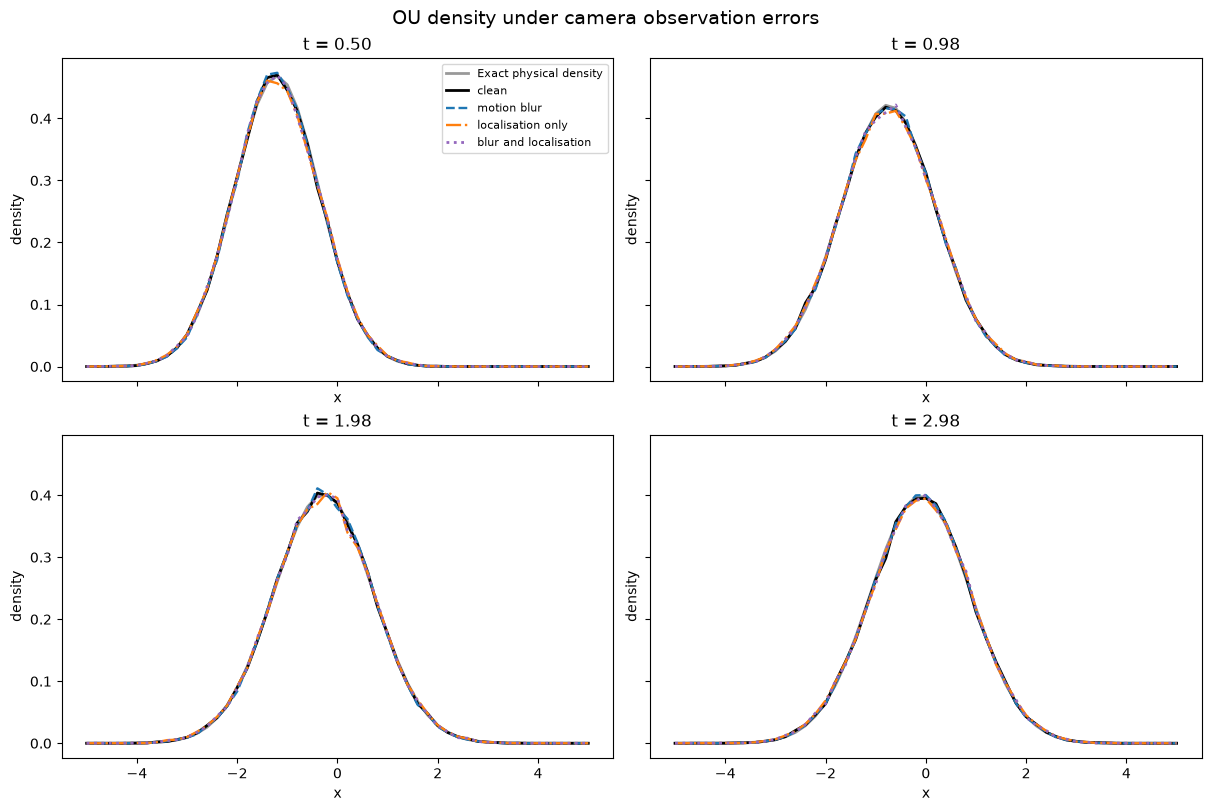

In [10]:
# Density snapshots on one common scale.
requested_snapshot_times = [0.5, 1.0, 2.0, 2.98]
snapshot_indices = [
    int(np.argmin(np.abs(t_camera - value)))
    for value in requested_snapshot_times
]

condition_styles = {
    "clean": {"color": "black", "linestyle": "-", "linewidth": 2.0},
    "motion_blur": {"color": "tab:blue", "linestyle": "--", "linewidth": 1.7},
    "localisation_only": {"color": "tab:orange", "linestyle": "-.", "linewidth": 1.7},
    "blur_and_localisation": {"color": "tab:purple", "linestyle": ":", "linewidth": 2.0},
}

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for time_index, ax in zip(snapshot_indices, axes.flat):
    ax.plot(
        x_em,
        rho_exact_em_grid[:, time_index],
        color="0.6",
        linewidth=2.0,
        label="Exact physical density",
    )

    for condition, style in condition_styles.items():
        ax.plot(
            x_em,
            rho_datasets[condition][:, time_index],
            label=condition.replace("_", " "),
            **style,
        )

    ax.set_title(f"t = {t_camera[time_index]:.2f}")
    ax.set_xlabel("x")
    ax.set_ylabel("density")

axes[0, 0].legend(fontsize=8)
fig.suptitle("OU density under camera observation errors", fontsize=14)
plt.show()


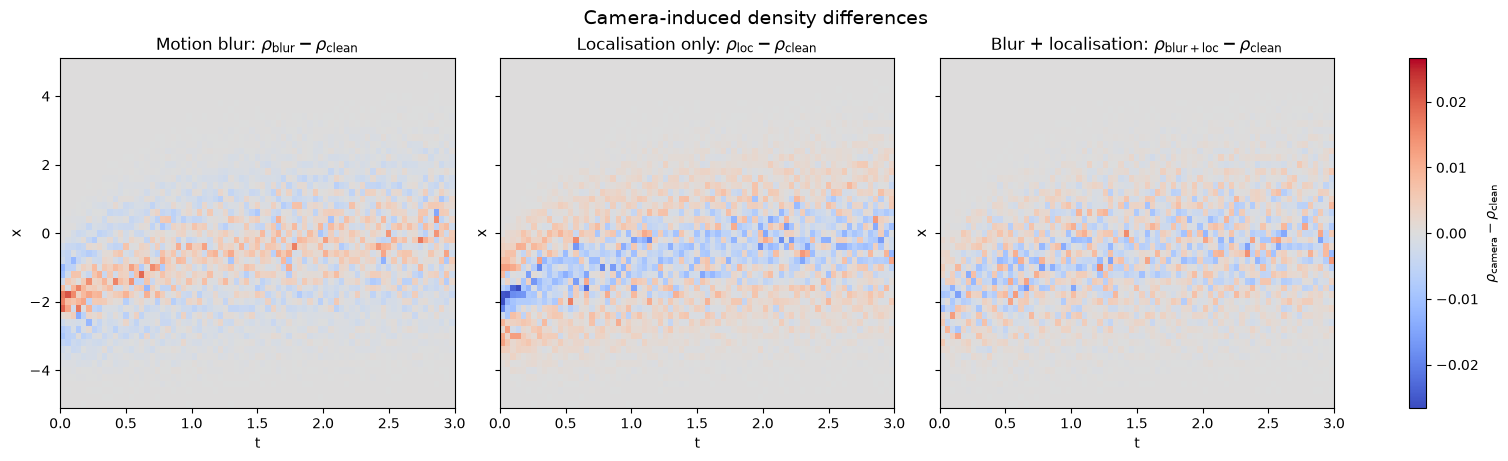

In [11]:
# Signed density differences relative to the paired clean histogram.
error_conditions = [
    "motion_blur",
    "localisation_only",
    "blur_and_localisation",
]
# Titles displayed in the figure
error_titles = {
    "motion_blur":
        r"Motion blur: $\rho_{\mathrm{blur}}-\rho_{\mathrm{clean}}$",

    "localisation_only":
        r"Localisation only: $\rho_{\mathrm{loc}}-\rho_{\mathrm{clean}}$",

    "blur_and_localisation":
        r"Blur + localisation: $\rho_{\mathrm{blur+loc}}-\rho_{\mathrm{clean}}$",
}

error_fields = {
    condition: rho_datasets[condition] - rho_datasets["clean"]
    for condition in error_conditions
}

common_error_limit = max(
    np.max(np.abs(error_field))
    for error_field in error_fields.values()
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4.5),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for ax, condition in zip(axes, error_conditions):
    image = ax.pcolormesh(
        t_camera,
        x_em,
        error_fields[condition],
        shading="auto",
        cmap="coolwarm",
        vmin=-common_error_limit,
        vmax=common_error_limit,
    )
    ax.set_title(error_titles[condition])
    ax.set_xlabel("t")
    ax.set_ylabel("x")

fig.colorbar(image, ax=axes, label=r"$\rho_{\rm camera}-\rho_{\rm clean}$")
fig.suptitle("Camera-induced density differences", fontsize=14)
plt.show()


## 6. Weak-SINDy candidate libraries

The five input fields are

$$
\rho,\qquad x\rho,\qquad x^2\rho,\qquad x\rho^2,\qquad x^2\rho^2.
$$

`WeakPDELibrary` constructs the zero-, first-, and second-order spatial weak features of every field, producing 15 columns.

The reduced **five-candidate library** is exactly the Week 7 library:

$$
\partial_x(x\rho),\quad
\partial_x(x^2\rho),\quad
\partial_x(x\rho^2),\quad
\partial_x(x^2\rho^2),\quad
\rho_{xx}.
$$

The complete **fifteen-candidate library** contains orders 0, 1, and 2 of every input field. For each camera condition, both regressions select columns from one common 15-column weak system, so they use the same weak target and the same randomly sampled subdomains. Resetting the same seed for every condition also aligns the sampled subdomains across camera datasets.


In [12]:
weak_input_names = [
    "rho",
    "xrho",
    "x2rho",
    "xrho2",
    "x2rho2",
]

feature_names_lib1 = [
    "xrho_1",
    "x2rho_1",
    "xrho2_1",
    "x2rho2_1",
    "rho_11",
]

weak_display_name = {
    "rho": r"$\rho$",
    "xrho": r"$x\rho$",
    "x2rho": r"$x^2\rho$",
    "xrho2": r"$x\rho^2$",
    "x2rho2": r"$x^2\rho^2$",
    "rho_1": r"$\rho_x$",
    "xrho_1": r"$(x\rho)_x$",
    "x2rho_1": r"$(x^2\rho)_x$",
    "xrho2_1": r"$(x\rho^2)_x$",
    "x2rho2_1": r"$(x^2\rho^2)_x$",
    "rho_11": r"$\rho_{xx}$",
    "xrho_11": r"$(x\rho)_{xx}$",
    "x2rho_11": r"$(x^2\rho)_{xx}$",
    "xrho2_11": r"$(x\rho^2)_{xx}$",
    "x2rho2_11": r"$(x^2\rho^2)_{xx}$",
}

# Physical OU coefficients. These remain the evaluation reference even when
# the camera observation process creates an effective observed equation.
weak_true_map = {
    "xrho_1": kappa,
    "rho_11": D,
}


In [13]:
def construct_weak_system(
    rho_data,
    x_grid,
    t_grid,
    K,
    full_width_fraction,
    random_seed,
):
    """Construct one complete 15-column weak system for rho(x,t)."""

    rho_data = np.asarray(rho_data, dtype=float)
    x_grid = np.asarray(x_grid, dtype=float)
    t_grid = np.asarray(t_grid, dtype=float)

    X_grid, T_grid = np.meshgrid(x_grid, t_grid, indexing="ij")

    if rho_data.shape != X_grid.shape:
        raise ValueError(
            f"rho_data has shape {rho_data.shape}, "
            f"but the coordinate grid has shape {X_grid.shape}."
        )

    XT_grid = np.stack((X_grid, T_grid), axis=-1)
    rho_state = rho_data[..., np.newaxis]

    candidate_controls = np.stack(
        [
            X_grid * rho_data,
            X_grid**2 * rho_data,
            X_grid * rho_data**2,
            X_grid**2 * rho_data**2,
        ],
        axis=-1,
    )

    weak_input_fields = np.concatenate(
        [rho_state, candidate_controls],
        axis=-1,
    )

    domain_lengths = np.array([
        x_grid[-1] - x_grid[0],
        t_grid[-1] - t_grid[0],
    ])

    # WeakPDELibrary expects half-widths; full_width_fraction is the
    # requested full support width as a fraction of each complete axis.
    H_xt = 0.5 * full_width_fraction * domain_lengths

    np.random.seed(random_seed)

    weak_library = ps.WeakPDELibrary(
        function_library=ps.IdentityLibrary(),
        derivative_order=2,
        spatiotemporal_grid=XT_grid,
        include_bias=False,
        include_interaction=False,
        K=int(K),
        H_xt=H_xt,
        p=4,
    )

    weak_library.fit(weak_input_fields)

    full_matrix = np.asarray(
        weak_library.transform(weak_input_fields)
    )

    full_feature_names = weak_library.get_feature_names(
        weak_input_names
    )

    weak_target = np.asarray(
        weak_library.convert_u_dot_integral(rho_state)
    )

    if full_matrix.shape[0] != weak_target.shape[0]:
        raise RuntimeError(
            "The weak design matrix and target have different row counts."
        )

    if full_matrix.shape[1] != 15:
        raise RuntimeError(
            f"Expected 15 weak candidate columns, got {full_matrix.shape[1]}."
        )

    return {
        "full_matrix": full_matrix,
        "full_feature_names": list(full_feature_names),
        "weak_target": weak_target,
        "H_xt": H_xt,
    }


In [14]:
def fit_one_weak_library(
    weak_system,
    selected_feature_names,
    library_name,
    condition_name,
):
    """Fit one selected library and return summary and coefficient rows."""

    full_matrix = weak_system["full_matrix"]
    full_feature_names = weak_system["full_feature_names"]
    weak_target = weak_system["weak_target"]

    selected_indices = [
        full_feature_names.index(name)
        for name in selected_feature_names
    ]

    regression_matrix = full_matrix[:, selected_indices]

    optimizer = ps.STLSQ(
        threshold=stlsq_threshold,
        alpha=stlsq_alpha,
        max_iter=1000,
        normalize_columns=True,
    )

    optimizer.fit(regression_matrix, weak_target)
    coefficients = optimizer.coef_.reshape(-1)

    physical_coefficients = np.array([
        weak_true_map.get(name, 0.0)
        for name in selected_feature_names
    ])

    camera_aware_map = {
        "xrho_1": kappa,
        "rho_11": camera_diffusion_reference[condition_name],
    }

    camera_aware_coefficients = np.array([
        camera_aware_map.get(name, 0.0)
        for name in selected_feature_names
    ])

    prediction = regression_matrix @ coefficients.reshape(-1, 1)

    identified_support = {
        name
        for name, coefficient in zip(selected_feature_names, coefficients)
        if abs(coefficient) > 1e-10
    }
    true_support = set(weak_true_map)

    coefficient_lookup = dict(zip(selected_feature_names, coefficients))

    summary_row = {
        "Condition": condition_name,
        "Library": library_name,
        "Number of candidate terms": len(selected_feature_names),
        "Number of nonzero coefficients": len(identified_support),
        "Number of spurious terms": len(identified_support - true_support),
        "Number of missed true terms": len(true_support - identified_support),
        "Correct support": identified_support == true_support,
        "Identified kappa": coefficient_lookup.get("xrho_1", 0.0),
        "Identified D": coefficient_lookup.get("rho_11", 0.0),
        "Physical reference D": D,
        "Camera-aware reference D": camera_diffusion_reference[
            condition_name
        ],
        "Relative error vs physical coefficients": relative_l2_error(
            coefficients,
            physical_coefficients,
        ),
        "Relative error vs camera-aware coefficients": relative_l2_error(
            coefficients,
            camera_aware_coefficients,
        ),
        "Relative weak residual": relative_l2_error(
            prediction,
            weak_target,
        ),
    }

    coefficient_rows = []
    for (
        name,
        coefficient,
        physical_coefficient,
        camera_aware_coefficient,
    ) in zip(
        selected_feature_names,
        coefficients,
        physical_coefficients,
        camera_aware_coefficients,
    ):
        coefficient_rows.append({
            "Condition": condition_name,
            "Library": library_name,
            "Feature key": name,
            "Candidate term": weak_display_name.get(name, name),
            "Identified coefficient": coefficient,
            "Physical coefficient": physical_coefficient,
            "Camera-aware coefficient": camera_aware_coefficient,
            "Absolute error vs physical": abs(
                coefficient - physical_coefficient
            ),
            "Absolute error vs camera-aware": abs(
                coefficient - camera_aware_coefficient
            ),
        })

    return summary_row, coefficient_rows


def run_condition_comparison(condition_name, rho_data):
    """Run the 5- and 15-candidate libraries on one common weak system."""

    weak_system = construct_weak_system(
        rho_data=rho_data,
        x_grid=x_em,
        t_grid=t_camera,
        K=K_weak,
        full_width_fraction=subdomain_full_width_fraction,
        random_seed=weak_subdomain_seed,
    )

    library_definitions = {
        "5 candidates": list(feature_names_lib1),
        "15 candidates": list(weak_system["full_feature_names"]),
    }

    summaries = []
    coefficient_rows = []

    for library_name, feature_names in library_definitions.items():
        summary, coefficients = fit_one_weak_library(
            weak_system=weak_system,
            selected_feature_names=feature_names,
            library_name=library_name,
            condition_name=condition_name,
        )
        summaries.append(summary)
        coefficient_rows.extend(coefficients)

    return summaries, coefficient_rows, weak_system


## 7. Run both candidate libraries for all four camera conditions

Every condition uses the same:

- physical latent trajectories;
- spatial and camera-time grids;
- $K=500$ weak equations;
- requested 25% subdomain full widths;
- subdomain seed;
- STLSQ threshold and ridge parameter.

Only the camera observation model and the selected candidate columns change.


In [15]:
condition_order = [
    "clean",
    "motion_blur",
    "localisation_only",
    "blur_and_localisation",
]

all_summary_rows = []
all_coefficient_rows = []
weak_systems = {}

for condition in condition_order:
    print(f"Running Weak SINDy for: {condition}")

    summaries, coefficient_rows, weak_system = run_condition_comparison(
        condition_name=condition,
        rho_data=rho_datasets[condition],
    )

    all_summary_rows.extend(summaries)
    all_coefficient_rows.extend(coefficient_rows)
    weak_systems[condition] = weak_system

comparison_results = pd.DataFrame(all_summary_rows)
coefficient_results = pd.DataFrame(all_coefficient_rows)

print("Completed regressions:", len(comparison_results))
print("Requested weak half-widths:", weak_systems["clean"]["H_xt"])

comparison_columns = [
    "Condition",
    "Library",
    "Number of candidate terms",
    "Number of nonzero coefficients",
    "Number of spurious terms",
    "Number of missed true terms",
    "Correct support",
    "Identified kappa",
    "Identified D",
    "Physical reference D",
    "Camera-aware reference D",
    "Relative error vs physical coefficients",
    "Relative error vs camera-aware coefficients",
    "Relative weak residual",
]

comparison_table = comparison_results[comparison_columns].copy()

display(
    comparison_table.style.format({
        "Identified kappa": "{:.6f}",
        "Identified D": "{:.6f}",
        "Physical reference D": "{:.6f}",
        "Camera-aware reference D": "{:.6f}",
        "Relative error vs physical coefficients": "{:.6e}",
        "Relative error vs camera-aware coefficients": "{:.6e}",
        "Relative weak residual": "{:.6e}",
    }).set_caption(
        "Weak-SINDy comparison with physical and camera-aware references"
    )
)


Running Weak SINDy for: clean
Running Weak SINDy for: motion_blur
Running Weak SINDy for: localisation_only
Running Weak SINDy for: blur_and_localisation
Completed regressions: 8
Requested weak half-widths: [1.25 0.37]


,Condition,Library,Number of candidate terms,Number of nonzero coefficients,Number of spurious terms,Number of missed true terms,Correct support,Identified kappa,Identified D,Physical reference D,Camera-aware reference D,Relative error vs physical coefficients,Relative error vs camera-aware coefficients,Relative weak residual
0,clean,5 candidates,5,2,0,0,True,1.012337,1.016750,1.000000,1.000000,1.471002e-02,1.471002e-02,6.208833e-02
1,clean,15 candidates,15,2,0,0,True,1.012337,1.016750,1.000000,1.000000,1.471002e-02,1.471002e-02,6.208833e-02
2,motion_blur,5 candidates,5,2,0,0,True,1.013313,1.003056,1.000000,0.986799,9.658884e-03,1.495695e-02,6.632304e-02
3,motion_blur,15 candidates,15,2,0,0,True,1.013313,1.003056,1.000000,0.986799,9.658884e-03,1.495695e-02,6.632304e-02
4,localisation_only,5 candidates,5,2,0,0,True,1.013222,1.039167,1.000000,1.020000,2.923116e-02,1.630161e-02,5.786740e-02
5,localisation_only,15 candidates,15,2,0,0,True,1.013222,1.039167,1.000000,1.020000,2.923116e-02,1.630161e-02,5.786740e-02
6,blur_and_localisation,5 candidates,5,2,0,0,True,1.012649,1.025256,1.000000,1.006799,1.997345e-02,1.576830e-02,5.747667e-02
7,blur_and_localisation,15 candidates,15,2,0,0,True,1.012649,1.025256,1.000000,1.006799,1.997345e-02,1.576830e-02,5.747667e-02


In [16]:
# Detailed coefficient tables and rendered equations.
for condition in condition_order:
    for library_name in ["5 candidates", "15 candidates"]:
        selected_rows = coefficient_results[
            (coefficient_results["Condition"] == condition)
            & (coefficient_results["Library"] == library_name)
        ]

        print(f"\n{condition} — {library_name}")

        display(
            selected_rows[
                [
                    "Candidate term",
                    "Identified coefficient",
                    "Physical coefficient",
                    "Camera-aware coefficient",
                    "Absolute error vs physical",
                    "Absolute error vs camera-aware",
                ]
            ].style.format({
                "Identified coefficient": "{:.6f}",
                "Physical coefficient": "{:.6f}",
                "Camera-aware coefficient": "{:.6f}",
                "Absolute error vs physical": "{:.3e}",
                "Absolute error vs camera-aware": "{:.3e}",
            })
        )

        print_identified_equation(
            selected_rows["Candidate term"].tolist(),
            selected_rows["Identified coefficient"].to_numpy(),
        )



clean — 5 candidates


,Candidate term,Identified coefficient,Physical coefficient,Camera-aware coefficient,Absolute error vs physical,Absolute error vs camera-aware
0,$(x\rho)_x$,1.012337,1.000000,1.000000,1.234e-02,1.234e-02
1,$(x^2\rho)_x$,0.000000,0.000000,0.000000,0.000e+00,0.000e+00
2,$(x\rho^2)_x$,0.000000,0.000000,0.000000,0.000e+00,0.000e+00
3,$(x^2\rho^2)_x$,0.000000,0.000000,0.000000,0.000e+00,0.000e+00
4,$\rho_{xx}$,1.016750,1.000000,1.000000,1.675e-02,1.675e-02


<IPython.core.display.Math object>


clean — 15 candidates


,Candidate term,Identified coefficient,Physical coefficient,Camera-aware coefficient,Absolute error vs physical,Absolute error vs camera-aware
5,$\rho$,0.000000,0.000000,0.000000,0.000e+00,0.000e+00
6,$x\rho$,0.000000,0.000000,0.000000,0.000e+00,0.000e+00
7,$x^2\rho$,0.000000,0.000000,0.000000,0.000e+00,0.000e+00
8,$x\rho^2$,0.000000,0.000000,0.000000,0.000e+00,0.000e+00
9,$x^2\rho^2$,0.000000,0.000000,0.000000,0.000e+00,0.000e+00
10,$\rho_x$,0.000000,0.000000,0.000000,0.000e+00,0.000e+00
11,$(x\rho)_x$,1.012337,1.000000,1.000000,1.234e-02,1.234e-02
12,$(x^2\rho)_x$,0.000000,0.000000,0.000000,0.000e+00,0.000e+00
13,$(x\rho^2)_x$,0.000000,0.000000,0.000000,0.000e+00,0.000e+00
14,$(x^2\rho^2)_x$,0.000000,0.000000,0.000000,0.000e+00,0.000e+00


...

,Candidate term,Identified coefficient,Physical coefficient,Camera-aware coefficient,Absolute error vs physical,Absolute error vs camera-aware
60,$(x\rho)_x$,1.012649,1.000000,1.000000,1.265e-02,1.265e-02
61,$(x^2\rho)_x$,0.000000,0.000000,0.000000,0.000e+00,0.000e+00
62,$(x\rho^2)_x$,0.000000,0.000000,0.000000,0.000e+00,0.000e+00
63,$(x^2\rho^2)_x$,0.000000,0.000000,0.000000,0.000e+00,0.000e+00
64,$\rho_{xx}$,1.025256,1.000000,1.006799,2.526e-02,1.846e-02


<IPython.core.display.Math object>


blur_and_localisation — 15 candidates


,Candidate term,Identified coefficient,Physical coefficient,Camera-aware coefficient,Absolute error vs physical,Absolute error vs camera-aware
65,$\rho$,0.000000,0.000000,0.000000,0.000e+00,0.000e+00
66,$x\rho$,0.000000,0.000000,0.000000,0.000e+00,0.000e+00
67,$x^2\rho$,0.000000,0.000000,0.000000,0.000e+00,0.000e+00
68,$x\rho^2$,0.000000,0.000000,0.000000,0.000e+00,0.000e+00
69,$x^2\rho^2$,0.000000,0.000000,0.000000,0.000e+00,0.000e+00
70,$\rho_x$,0.000000,0.000000,0.000000,0.000e+00,0.000e+00
71,$(x\rho)_x$,1.012649,1.000000,1.000000,1.265e-02,1.265e-02
72,$(x^2\rho)_x$,0.000000,0.000000,0.000000,0.000e+00,0.000e+00
73,$(x\rho^2)_x$,0.000000,0.000000,0.000000,0.000e+00,0.000e+00
74,$(x^2\rho^2)_x$,0.000000,0.000000,0.000000,0.000e+00,0.000e+00


<IPython.core.display.Math object>

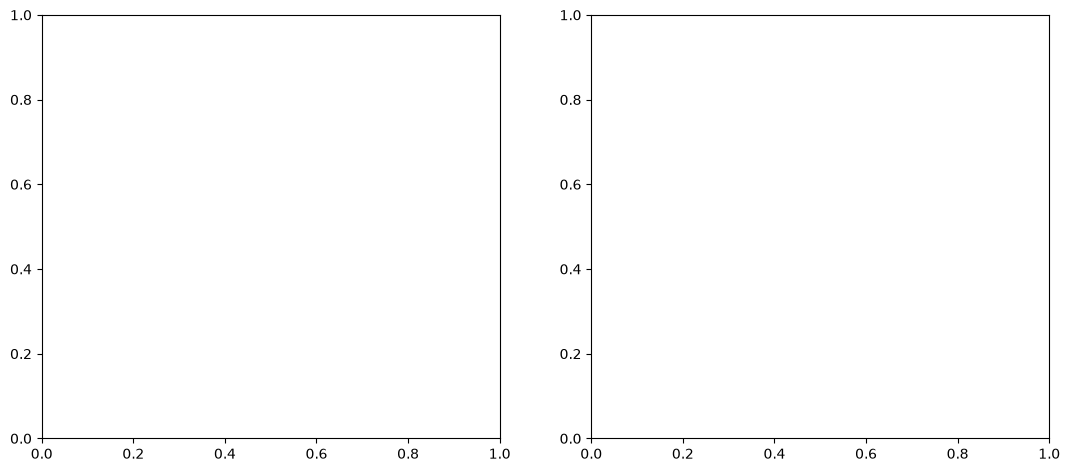

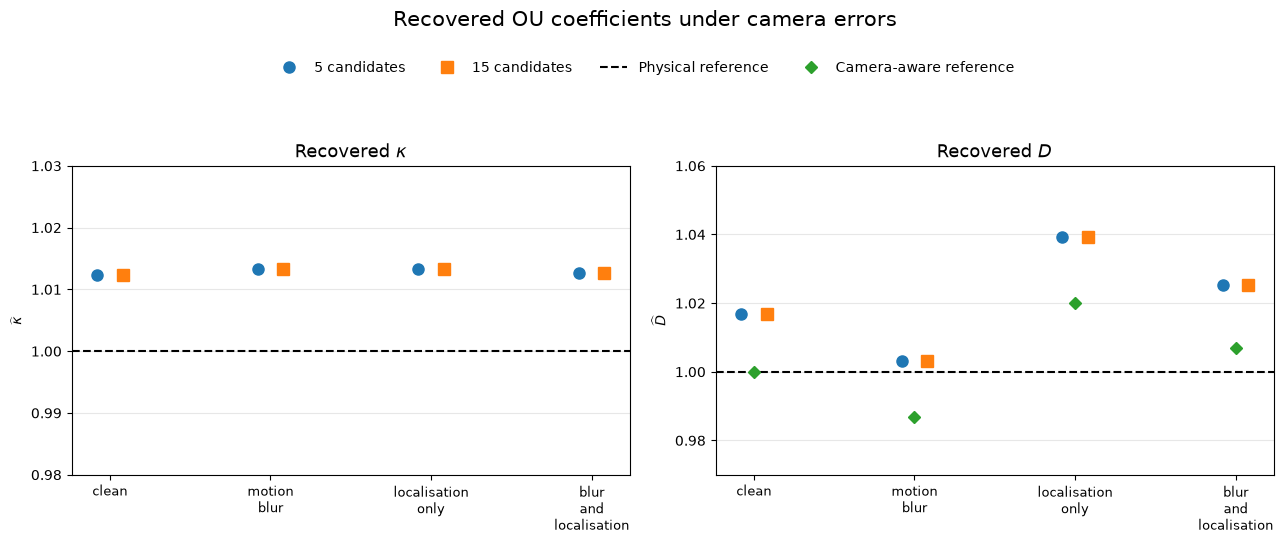

In [17]:
library_order = ["5 candidates", "15 candidates"]

x_positions = np.arange(len(condition_order))
offsets = [-0.08, 0.08]
colors = ["tab:blue", "tab:orange"]
markers = ["o", "s"]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5.5),
)

for library_index, library_name in enumerate(library_order):
    rows = (
        comparison_results[
            comparison_results["Library"] == library_name
        ]
        .set_index("Condition")
        .loc[condition_order]
    )

    x_shifted = x_positions + offsets[library_index]

    axes[0].plot(
        x_shifted,
        rows["Identified kappa"],
        linestyle="none",
        marker=markers[library_index],
        markersize=8,
        color=colors[library_index],
        label=library_name,
    )

    axes[1].plot(
        x_shifted,
        rows["Identified D"],
        linestyle="none",
        marker=markers[library_index],
        markersize=8,
        color=colors[library_index],
        label=library_name,
    )

axes[0].axhline(
    kappa,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Physical reference",
)

axes[1].axhline(
    D,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Physical reference",
)

camera_reference_values = np.array([
    camera_diffusion_reference[condition]
    for condition in condition_order
])

axes[1].plot(
    x_positions,
    camera_reference_values,
    linestyle="none",
    marker="D",
    markersize=6,
    color="tab:green",
    label="Camera-aware reference",
)

for ax, title, ylabel in zip(
    axes,
    [r"Recovered $\kappa$", r"Recovered $D$"],
    [r"$\widehat{\kappa}$", r"$\widehat{D}$"],
):
    ax.set_xticks(x_positions)
    ax.set_xticklabels(
        [name.replace("_", "\n") for name in condition_order],
        fontsize=9,
    )
    ax.set_title(title, fontsize=13)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylim(0.98, 1.03)
axes[1].set_ylim(0.97, 1.06)

legend_entries = {}
for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    for handle, label in zip(handles, labels):
        legend_entries.setdefault(label, handle)

fig.suptitle(
    "Recovered OU coefficients under camera errors",
    fontsize=15,
    y=0.98,
)

fig.legend(
    legend_entries.values(),
    legend_entries.keys(),
    loc="upper center",
    bbox_to_anchor=(0.5, 0.91),
    ncol=4,
    frameon=False,
)

fig.tight_layout(rect=[0.0, 0.0, 1.0, 0.83])
plt.show()


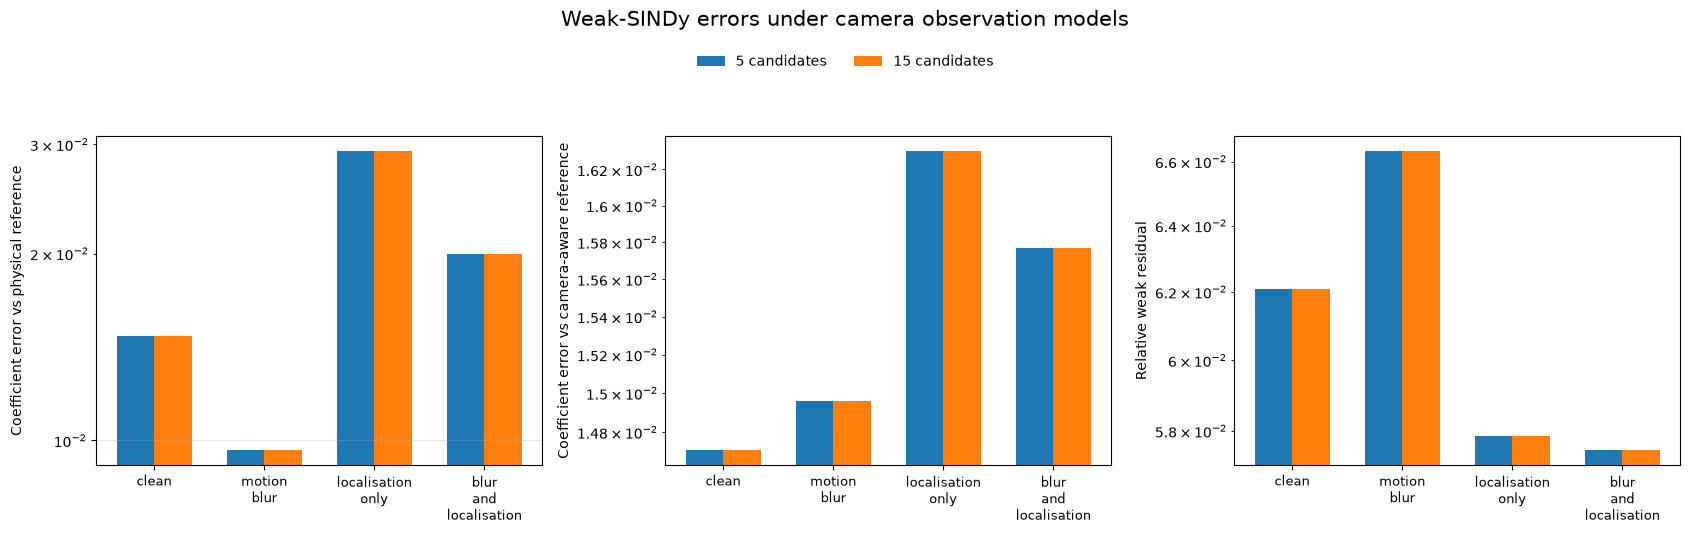

In [18]:
metrics = [
    (
        "Relative error vs physical coefficients",
        "Coefficient error vs physical reference",
    ),
    (
        "Relative error vs camera-aware coefficients",
        "Coefficient error vs camera-aware reference",
    ),
    (
        "Relative weak residual",
        "Relative weak residual",
    ),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5.4))
bar_width = 0.34

for ax, (metric, ylabel) in zip(axes, metrics):
    for library_index, library_name in enumerate(library_order):
        rows = (
            comparison_results[
                comparison_results["Library"] == library_name
            ]
            .set_index("Condition")
            .loc[condition_order]
        )

        offset = (library_index - 0.5) * bar_width
        ax.bar(
            x_positions + offset,
            rows[metric],
            width=bar_width,
            label=library_name,
        )

    ax.set_yscale("log")
    ax.set_xticks(x_positions)
    ax.set_xticklabels(
        [name.replace("_", "\n") for name in condition_order],
        fontsize=9,
    )
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()

fig.suptitle(
    "Weak-SINDy errors under camera observation models",
    fontsize=15,
    y=0.98,
)

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.92),
    ncol=2,
    frameon=False,
)

fig.tight_layout(rect=[0.0, 0.0, 1.0, 0.84])
plt.show()


## Conclusion

For the tested setting of 60,000 latent trajectories, $K=500$, 25% requested
full widths, $\widetilde{\sigma}=0.5$, and full-frame exposure, both the
five-candidate and fifteen-candidate libraries select exactly
$\partial_x(x\rho)$ and $\rho_{xx}$ for all four observation conditions.

This demonstrates support robustness within the tested parameter regime.
It does not imply that the physical coefficients remain unchanged.

Motion blur reduces the effective diffusion of the observed marginal density,
while localisation error increases it. The coefficient tables therefore
report errors relative to both the underlying physical value $D=1$ and the
camera-aware observed-density reference.

In this linear-Gaussian OU example, the camera model preserves the two-term
operator support but changes the effective diffusion coefficient and the
observed initial distribution. This property should not be assumed for
nonlinear drift, state-dependent diffusion, or more general observation
models.

Stronger robustness claims would require independent trajectory seeds and
sweeps over localisation strength, exposure duration, weak-domain parameters,
and the STLSQ threshold.